# The label ceiling — what are we actually measuring against?

Every sentiment and priority number in this project is scored against labels the
**v5 prompt generated**, not against ground truth. A model that scores 1.0 has
learned to reproduce v5 perfectly, including wherever v5 is wrong.

So before spending more GPU time: **how good is v5?**

`datasets/english/500_benchmarkset.csv` holds 500 human-annotated tickets. That
makes it the only ground truth in the project, and comparing v5 against it puts
a ceiling on every model score.

Unlike `category`, which comes from BANKING77 upstream and is genuine ground
truth, sentiment and priority were invented by a prompt.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd()
while not (REPO / "ml" / "swiftbench").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "ml"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, cohen_kappa_score, confusion_matrix,
                             f1_score)

import swiftbench as sb

pd.set_option("display.width", 200)

gold = pd.read_csv(REPO / "datasets" / "english" / "500_benchmarkset.csv")
train = pd.read_csv(REPO / "datasets" / "english" / "train_labeled.csv")

merged = gold.merge(train[["id", "text", "category", "sentiment", "priority"]],
                    left_on="row_id", right_on="id", suffixes=("_gold", "_v5"))

assert len(merged) == 500
assert (merged.text_gold.str.strip() == merged.text_v5.str.strip()).all()
print(f"aligned {len(merged)} rows on row_id -> id, text identical in every row")
print(f"annotators: {gold.annotator.value_counts().to_dict()}")

aligned 500 rows on row_id -> id, text identical in every row
annotators: {1: 500}


## 1. Agreement between v5 and the human annotator

In [2]:
def ci(fn, a, b, n_boot=3000, seed=0):
    rng = np.random.default_rng(seed)
    stats = []
    for _ in range(n_boot):
        i = rng.integers(0, len(a), len(a))
        try:
            stats.append(fn(a[i], b[i]))
        except ValueError:
            continue
    return np.percentile(stats, [2.5, 97.5])


rows = []
specs = [("sentiment", lambda a, b: f1_score(a, b, pos_label="Negative"), "negative_f1"),
         ("priority", lambda a, b: f1_score(a, b, average="macro"), "macro_f1"),
         ("category", lambda a, b: f1_score(a, b, average="macro"), "macro_f1")]

for task, fn, metric in specs:
    g = merged[f"{task}_gold"].values
    v = merged[f"{task}_v5"].values
    lo, hi = ci(fn, g, v)
    rows.append({"task": task, "metric": metric,
                 "v5_vs_human": round(fn(g, v), 4),
                 "ci_low": round(lo, 4), "ci_high": round(hi, 4),
                 "agreement": round(accuracy_score(g, v), 4),
                 "cohen_kappa": round(cohen_kappa_score(g, v), 4)})

ceiling = pd.DataFrame(rows)
ceiling.to_csv(REPO / "ml" / "reports" / "label_ceiling.csv", index=False)
display(ceiling)

print("`category` agrees perfectly because it comes from BANKING77 upstream —")
print("the annotator did not invent it. That is what real ground truth looks like.")
print("Sentiment and priority were generated by the v5 prompt, and do not.")

,task,metric,v5_vs_human,ci_low,ci_high,agreement,cohen_kappa
0,sentiment,negative_f1,0.5769,0.4000,0.7273,0.956,0.5546
1,priority,macro_f1,0.7722,0.7263,0.8147,0.804,0.6446
2,category,macro_f1,1.0000,1.0000,1.0000,1.000,1.0000


`category` agrees perfectly because it comes from BANKING77 upstream —
the annotator did not invent it. That is what real ground truth looks like.
Sentiment and priority were generated by the v5 prompt, and do not.


### Where v5 and the human disagree on sentiment

In [3]:
g = merged.sentiment_gold
v = merged.sentiment_v5
cm = confusion_matrix(g, v, labels=["Neutral", "Negative"])
display(pd.DataFrame(cm, index=["human Neutral", "human Negative"],
                     columns=["v5 Neutral", "v5 Negative"]))

missed = merged[(g == "Negative") & (v == "Neutral")]
print(f"v5 recall on human-Negative: "
      f"{((g == 'Negative') & (v == 'Negative')).sum()}/{(g == 'Negative').sum()} "
      f"= {((g == 'Negative') & (v == 'Negative')).sum() / (g == 'Negative').sum():.3f}")
print(f"\nv5 calls {len(missed)} human-Negative tickets Neutral. Sample:")
for _, r in missed.head(8).iterrows():
    print(f"  [{r.category_gold}] {str(r.text_gold)[:88]}")

,v5 Neutral,v5 Negative
human Neutral,463,6
human Negative,16,15


v5 recall on human-Negative: 15/31 = 0.484

v5 calls 16 human-Negative tickets Neutral. Sample:
  [declined_transfer] Hello. My credit keeps being declined, last night and again today, as I try to buy somet
  [extra_charge_on_statement] I am being charged Rs 10 out of nowhere. What is this?
  [declined_card_payment] I keep trying to make a payment, but it doesn't work.
  [cash_withdrawal_not_recognised] The app says I made a cash withdrawal even though I didn't.
  [failed_transfer] Hi, can you tell me why my transfer keeps being rejected? I've been trying to send money
  [pending_transfer] I am still waiting for a transfer to show
  [why_verify_identity] Why do you guys need to verify my identity?
  [pending_card_payment] My card payment is just showing up as pending since forever, what's going on with that, 


## 2. The ceiling against measured model performance

This is the comparison that should govern what happens next.

,task,model_vs_v5_labels,v5_vs_human,ceiling_ci,headroom,note
0,sentiment,0.5525,0.5769,"[0.4, 0.7273]",0.0244,"tfidf-svm 5-fold CV, tuned C"
1,priority,0.9119,0.7722,"[0.7263, 0.8147]",-0.1397,"tfidf-svm class_weight, dev"


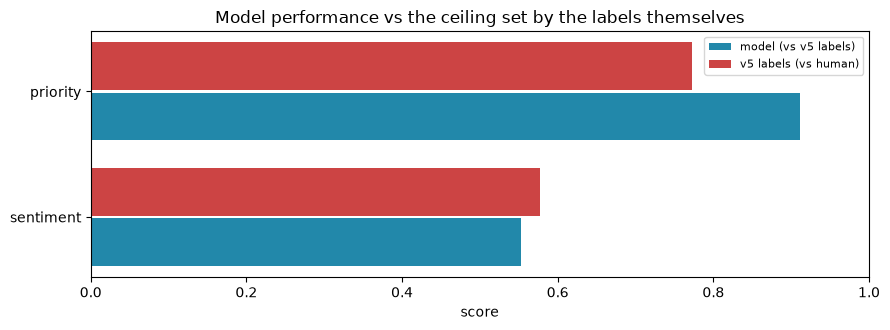

In [4]:
MODEL = {"sentiment": (0.5525, 0.0444, "tfidf-svm 5-fold CV, tuned C"),
         "priority": (0.9119, None, "tfidf-svm class_weight, dev")}

comp = []
for task, (score, std, note) in MODEL.items():
    c = ceiling[ceiling.task == task].iloc[0]
    comp.append({"task": task,
                 "model_vs_v5_labels": score,
                 "v5_vs_human": c.v5_vs_human,
                 "ceiling_ci": f"[{c.ci_low}, {c.ci_high}]",
                 "headroom": round(c.v5_vs_human - score, 4),
                 "note": note})
comp_df = pd.DataFrame(comp)
display(comp_df)

fig, ax = plt.subplots(figsize=(9, 3.4))
y = np.arange(len(comp_df))
ax.barh(y - 0.2, comp_df.model_vs_v5_labels, 0.38, label="model (vs v5 labels)", color="#28a")
ax.barh(y + 0.2, comp_df.v5_vs_human, 0.38, label="v5 labels (vs human)", color="#c44")
ax.set_yticks(y); ax.set_yticklabels(comp_df.task)
ax.set_xlabel("score"); ax.set_xlim(0, 1)
ax.set_title("Model performance vs the ceiling set by the labels themselves")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 3. What this means

**Sentiment — the model is already at the ceiling.**

The classical model scores 0.5525 against v5 labels. v5 itself scores 0.5769
against human judgement, with a CI of roughly [0.40, 0.73]. There is about
**0.02 of headroom**, and it is buried inside the uncertainty.

Pushing a model from 0.55 to 0.70 against v5 labels does not mean it got better
at sentiment. It means it learned to reproduce v5's mistakes more faithfully —
and since v5 misses half of the human-Negative tickets, a model that matched v5
perfectly would still miss half of them. **Optimising harder against v5 makes
the product worse, not better, past this point.**

**Priority — the model is scoring above its own ceiling.**

The model hits 0.9119 against v5 labels while v5 agrees with the human at only
0.7722 macro-F1. That is not a better model; it is a model that has learned v5's
systematic biases very well. Real human-aligned priority accuracy is bounded
near 0.77, not 0.91. The reported 0.9119 is a measure of *v5-reproduction
fidelity*, and should be labelled as such wherever it is quoted.

### Caveats that limit how hard to lean on this

- **One annotator.** No inter-annotator agreement was measured, so we cannot
  separate "v5 is wrong" from "this ticket is genuinely ambiguous". A second
  annotator on the same 500 rows would settle it and is cheap.
- **31 Negative rows** in the gold set. The sentiment ceiling CI is
  correspondingly wide.
- **All 500 rows sit inside train**, so this set can measure the labels but must
  never be used as a test set.
- The human annotation is itself one person's reading of a deliberately binary
  scheme with no `Positive` class.

## 4. Recommended next steps

In priority order, and note that none of them is "train a bigger model":

1. **Second annotator on the same 500 rows.** Establishes whether the ceiling is
   v5's error or genuine ambiguity. Cheapest, most decisive.
2. **If v5 is the problem, fix v5** — its Negative recall against the human is
   0.484. A v6 prompt targeting recall on Negative would raise the ceiling for
   every model at once, which no amount of fine-tuning can do.
3. **Re-label, then re-measure.** Every model score in this project moves when
   the labels move.
4. **Only then** revisit encoders. The mmBERT run currently in flight is still
   worth finishing — but read its result against 0.5769, not against 1.0.

Report the distinction explicitly from now on: *"0.55 Negative-F1 against
v5-generated labels, which themselves agree with human annotation at 0.58"* is
the honest sentence. The bare number is not.